In [25]:
import pandas as pd
df=pd.read_excel("Dataset.xlsx")
df

,section,description,case study
0,300,"Murder,\nWhen culpable homicide is not murder",\nA person was attacked by an armed assailant ...
1,300,"Murder,\nWhen culpable homicide is not murder",\nTwo individuals engaged in a heated argument...
2,300,"Murder,\nWhen culpable homicide is not murder",\nA group of friends was involved in a prank w...
3,300,"Murder,\nWhen culpable homicide is not murder","\nDuring a medical procedure or surgery, a sur..."
4,300,"Murder,\nWhen culpable homicide is not murder",Accidental Discharge of a Firearm:\nIn a case ...
...,...,...,...
640,420,Cheating and Dishonestly Inducing Delivery of ...,An individual advertised products for sale on...
641,420,Cheating and Dishonestly Inducing Delivery of ...,A group of individuals convinced victims to in...
642,420,Cheating and Dishonestly Inducing Delivery of ...,Fraudsters used deceptive tactics to obtain pa...
643,420,Cheating and Dishonestly Inducing Delivery of ...,Cybercriminals gained access to victims' inte...


In [26]:
df.isnull().sum()

section        0
description    0
case study     0
dtype: int64

In [27]:
df["case study"] = df['description'].astype(str) +" "+ df["case study"].astype(str)
df

,section,description,case study
0,300,"Murder,\nWhen culpable homicide is not murder","Murder,\nWhen culpable homicide is not murder ..."
1,300,"Murder,\nWhen culpable homicide is not murder","Murder,\nWhen culpable homicide is not murder ..."
2,300,"Murder,\nWhen culpable homicide is not murder","Murder,\nWhen culpable homicide is not murder ..."
3,300,"Murder,\nWhen culpable homicide is not murder","Murder,\nWhen culpable homicide is not murder ..."
4,300,"Murder,\nWhen culpable homicide is not murder","Murder,\nWhen culpable homicide is not murder ..."
...,...,...,...
640,420,Cheating and Dishonestly Inducing Delivery of ...,Cheating and Dishonestly Inducing Delivery of ...
641,420,Cheating and Dishonestly Inducing Delivery of ...,Cheating and Dishonestly Inducing Delivery of ...
642,420,Cheating and Dishonestly Inducing Delivery of ...,Cheating and Dishonestly Inducing Delivery of ...
643,420,Cheating and Dishonestly Inducing Delivery of ...,Cheating and Dishonestly Inducing Delivery of ...


In [28]:
df.section.unique()

array([300, 301, 302, 303, 304, '304A', '304B', 305, 307, 308, 310, 319,
       320, 321, 322, 323, 324, 325, 326, '326A', '326B', 327, 328, 329,
       330, 331, 332, 333, 334, 335, 336, 337, 338, 339, 340, 341, 342,
       343, 344, 345, 346, 347, 348, 349, 350, 351, 352, 353, 354, '354A',
       '354B', '354C', '354D', 355, 356, 357, 358, 359, 360, 361, 362,
       363, '363A', 364, '364A', 365, 366, '366A', '366B', 367, 368, 369,
       370, '370A', 371, 372, 373, 374, 375, 376, '376A', '376B', '376C',
       '376D', '376E', 377, 378, 379, 380, 381, 382, 383, 384, 385, 386,
       387, 388, 389, 390, 391, 392, 393, 394, 395, 396, 397, 398, 399,
       400, 401, 402, 403, 404, 405, 406, 407, 408, 409, 410, 411, 412,
       413, 414, 415, 416, 417, 418, 419, 420], dtype=object)

In [29]:
df.section.nunique()

129

In [30]:
import nltk 
def remove_stopwords(text):
    stopwords=nltk.corpus.stopwords.words('english')
    clean_text=' '.join([word for word in text.split() if word not in stopwords])
    return clean_text

from nltk.stem.porter import PorterStemmer
def cleanup_data(df):
    # remove handle
    df['clean'] = df["case study"].str.replace("@", "") 
    # remove links
    df['clean'] = df['clean'].str.replace(r"http\S+", "") 
    # remove punctuations and special characters
    df['clean'] = df['clean'].str.replace("[^a-zA-Z]", " ") 
    # remove stop words
    df['clean'] = df['clean'].apply(lambda text : remove_stopwords(text.lower()))
    # split text and tokenize
    df['clean'] = df['clean'].apply(lambda x: x.split())
    # let's apply stemmer
    stemmer = PorterStemmer()
    df['clean'] = df['clean'].apply(lambda x: [stemmer.stem(i) for i in x])
    # stitch back words
    df['clean'] = df['clean'].apply(lambda x: ' '.join([w for w in x]))
    # remove small words
    df['clean'] = df['clean'].apply(lambda x: ' '.join([w for w in x.split() if len(w)>3]))
cleanup_data(df)
df

,section,description,case study,clean
0,300,"Murder,\nWhen culpable homicide is not murder","Murder,\nWhen culpable homicide is not murder ...","murder, culpabl homicid murder person attack a..."
1,300,"Murder,\nWhen culpable homicide is not murder","Murder,\nWhen culpable homicide is not murder ...","murder, culpabl homicid murder individu engag ..."
2,300,"Murder,\nWhen culpable homicide is not murder","Murder,\nWhen culpable homicide is not murder ...","murder, culpabl homicid murder group friend in..."
3,300,"Murder,\nWhen culpable homicide is not murder","Murder,\nWhen culpable homicide is not murder ...","murder, culpabl homicid murder medic procedur ..."
4,300,"Murder,\nWhen culpable homicide is not murder","Murder,\nWhen culpable homicide is not murder ...","murder, culpabl homicid murder accident discha..."
...,...,...,...,...
640,420,Cheating and Dishonestly Inducing Delivery of ...,Cheating and Dishonestly Inducing Delivery of ...,cheat dishonestli induc deliveri properti indi...
641,420,Cheating and Dishonestly Inducing Delivery of ...,Cheating and Dishonestly Inducing Delivery of ...,cheat dishonestli induc deliveri properti grou...
642,420,Cheating and Dishonestly Inducing Delivery of ...,Cheating and Dishonestly Inducing Delivery of ...,cheat dishonestli induc deliveri properti frau...
643,420,Cheating and Dishonestly Inducing Delivery of ...,Cheating and Dishonestly Inducing Delivery of ...,cheat dishonestli induc deliveri properti cybe...


In [31]:
data = [x[0] for x in df[['clean']].to_records(index=False)]
labels = [x[0] for x in df[["section"]].to_records(index=False)]
from sklearn.feature_extraction.text import TfidfVectorizer
extra_params={'min_df': 0.001}
vectorizer = TfidfVectorizer(**extra_params)
# feature vectors
data_vect = vectorizer.fit_transform(data)
print(data_vect.shape)

(645, 2820)


In [32]:
vectorizer.get_feature_names_out()

array(['10', '11', '12', ..., 'zidan', 'zinedin', 'zones'], dtype=object)

In [33]:
# get idf values
print('\nidf values:')
for ele1, ele2 in zip(vectorizer.get_feature_names_out(), vectorizer.idf_):
    print(ele1, ':', ele2)


idf values:
10 : 6.777652323222656
11 : 6.777652323222656
12 : 6.777652323222656
13 : 6.777652323222656
14 : 6.372187215114492
17 : 6.372187215114492
1871 : 6.777652323222656
19 : 6.084505142662711
1916 : 6.777652323222656
1920 : 6.777652323222656
1930s : 6.372187215114492
1931 : 6.777652323222656
1934 : 6.372187215114492
1969 : 6.084505142662711
1978 : 6.777652323222656
1979 : 6.777652323222656
1980 : 6.777652323222656
1980s : 6.777652323222656
1981 : 6.777652323222656
1982 : 6.777652323222656
1983 : 6.777652323222656
1984 : 6.777652323222656
1989 : 6.777652323222656
1990s : 6.777652323222656
1991 : 6.777652323222656
1993 : 6.084505142662711
1994 : 6.084505142662711
1995 : 6.777652323222656
1996 : 6.777652323222656
1997 : 6.777652323222656
1999 : 6.372187215114492
2000 : 6.777652323222656
2001 : 6.372187215114492
2002 : 6.372187215114492
2003 : 6.777652323222656
2005 : 6.372187215114492
2006 : 5.679040034554547
2007 : 6.084505142662711
2008 : 6.777652323222656
2009 : 5.67904003455454

In [34]:
print(vectorizer.vocabulary_)

{'murder': 1737, 'culpabl': 705, 'homicid': 1279, 'person': 1934, 'attack': 290, 'assail': 275, 'dark': 735, 'alley': 209, 'self': 2314, 'defense': 768, 'victim': 2718, 'fought': 1119, 'back': 315, 'manag': 1626, 'disarm': 823, 'attacker': 291, 'however': 1297, 'struggle': 2476, 'killed': 1491, 'case': 482, 'argu': 259, 'defens': 767, 'protect': 2065, 'life': 1564, 'classifi': 548, 'individu': 1339, 'engag': 938, 'heat': 1244, 'argument': 260, 'escal': 957, 'sudden': 2490, 'physic': 1945, 'fight': 1070, 'brawl': 407, 'deliv': 774, 'fatal': 1051, 'blow': 375, 'other': 1846, 'result': 2213, 'death': 748, 'establish': 965, 'occur': 1803, 'moment': 1721, 'without': 2785, 'prior': 2022, 'intent': 1392, 'planning': 1954, 'amount': 225, 'group': 1198, 'friend': 1136, 'involv': 1416, 'prank': 1993, 'intend': 1389, 'scare': 2289, 'anoth': 236, 'pretend': 2012, 'harm': 1229, 'them': 2567, 'went': 2764, 'horribl': 1283, 'wrong': 2803, 'suffer': 2491, 'heart': 1243, 'extrem': 1022, 'fear': 1057, '

In [35]:
data_vect.toarray()

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [36]:
#split data
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(data_vect, labels, test_size=0.20)
print(len(y_train), len(y_test))

516 129


K-Nearest Neighbors
              precision    recall  f1-score   support

         300       1.00      1.00      1.00         1
         301       1.00      1.00      1.00         1
         304       1.00      1.00      1.00         1
        304A       1.00      1.00      1.00         1
         305       1.00      1.00      1.00         1
         308       1.00      1.00      1.00         3
         319       0.00      0.00      0.00         1
         320       1.00      1.00      1.00         1
         321       0.00      0.00      0.00         0
         322       1.00      0.67      0.80         3
         324       1.00      1.00      1.00         2
         325       0.00      0.00      0.00         1
        326A       1.00      1.00      1.00         1
         328       1.00      1.00      1.00         2
         329       1.00      1.00      1.00         2
         330       0.50      1.00      0.67         1
         331       0.00      0.00      0.00         1
       

Decision Tree
              precision    recall  f1-score   support

         300       1.00      1.00      1.00         1
         301       1.00      1.00      1.00         1
         304       1.00      1.00      1.00         1
        304A       1.00      1.00      1.00         1
         305       1.00      1.00      1.00         1
         308       1.00      1.00      1.00         3
         319       1.00      1.00      1.00         1
         320       1.00      1.00      1.00         1
         322       1.00      1.00      1.00         3
         324       1.00      1.00      1.00         2
         325       1.00      1.00      1.00         1
        326A       1.00      1.00      1.00         1
         328       1.00      1.00      1.00         2
         329       1.00      1.00      1.00         2
         330       1.00      1.00      1.00         1
         331       1.00      1.00      1.00         1
         333       1.00      1.00      1.00         1
         335 

ExtraTreesClassifier
              precision    recall  f1-score   support

         300       1.00      1.00      1.00         1
         301       1.00      1.00      1.00         1
         304       1.00      1.00      1.00         1
        304A       1.00      1.00      1.00         1
         305       1.00      1.00      1.00         1
         308       1.00      1.00      1.00         3
         319       1.00      1.00      1.00         1
         320       1.00      1.00      1.00         1
         322       1.00      1.00      1.00         3
         324       1.00      1.00      1.00         2
         325       1.00      1.00      1.00         1
        326A       1.00      1.00      1.00         1
         328       1.00      1.00      1.00         2
         329       1.00      1.00      1.00         2
         330       1.00      1.00      1.00         1
         331       1.00      1.00      1.00         1
         333       1.00      1.00      1.00         1
      

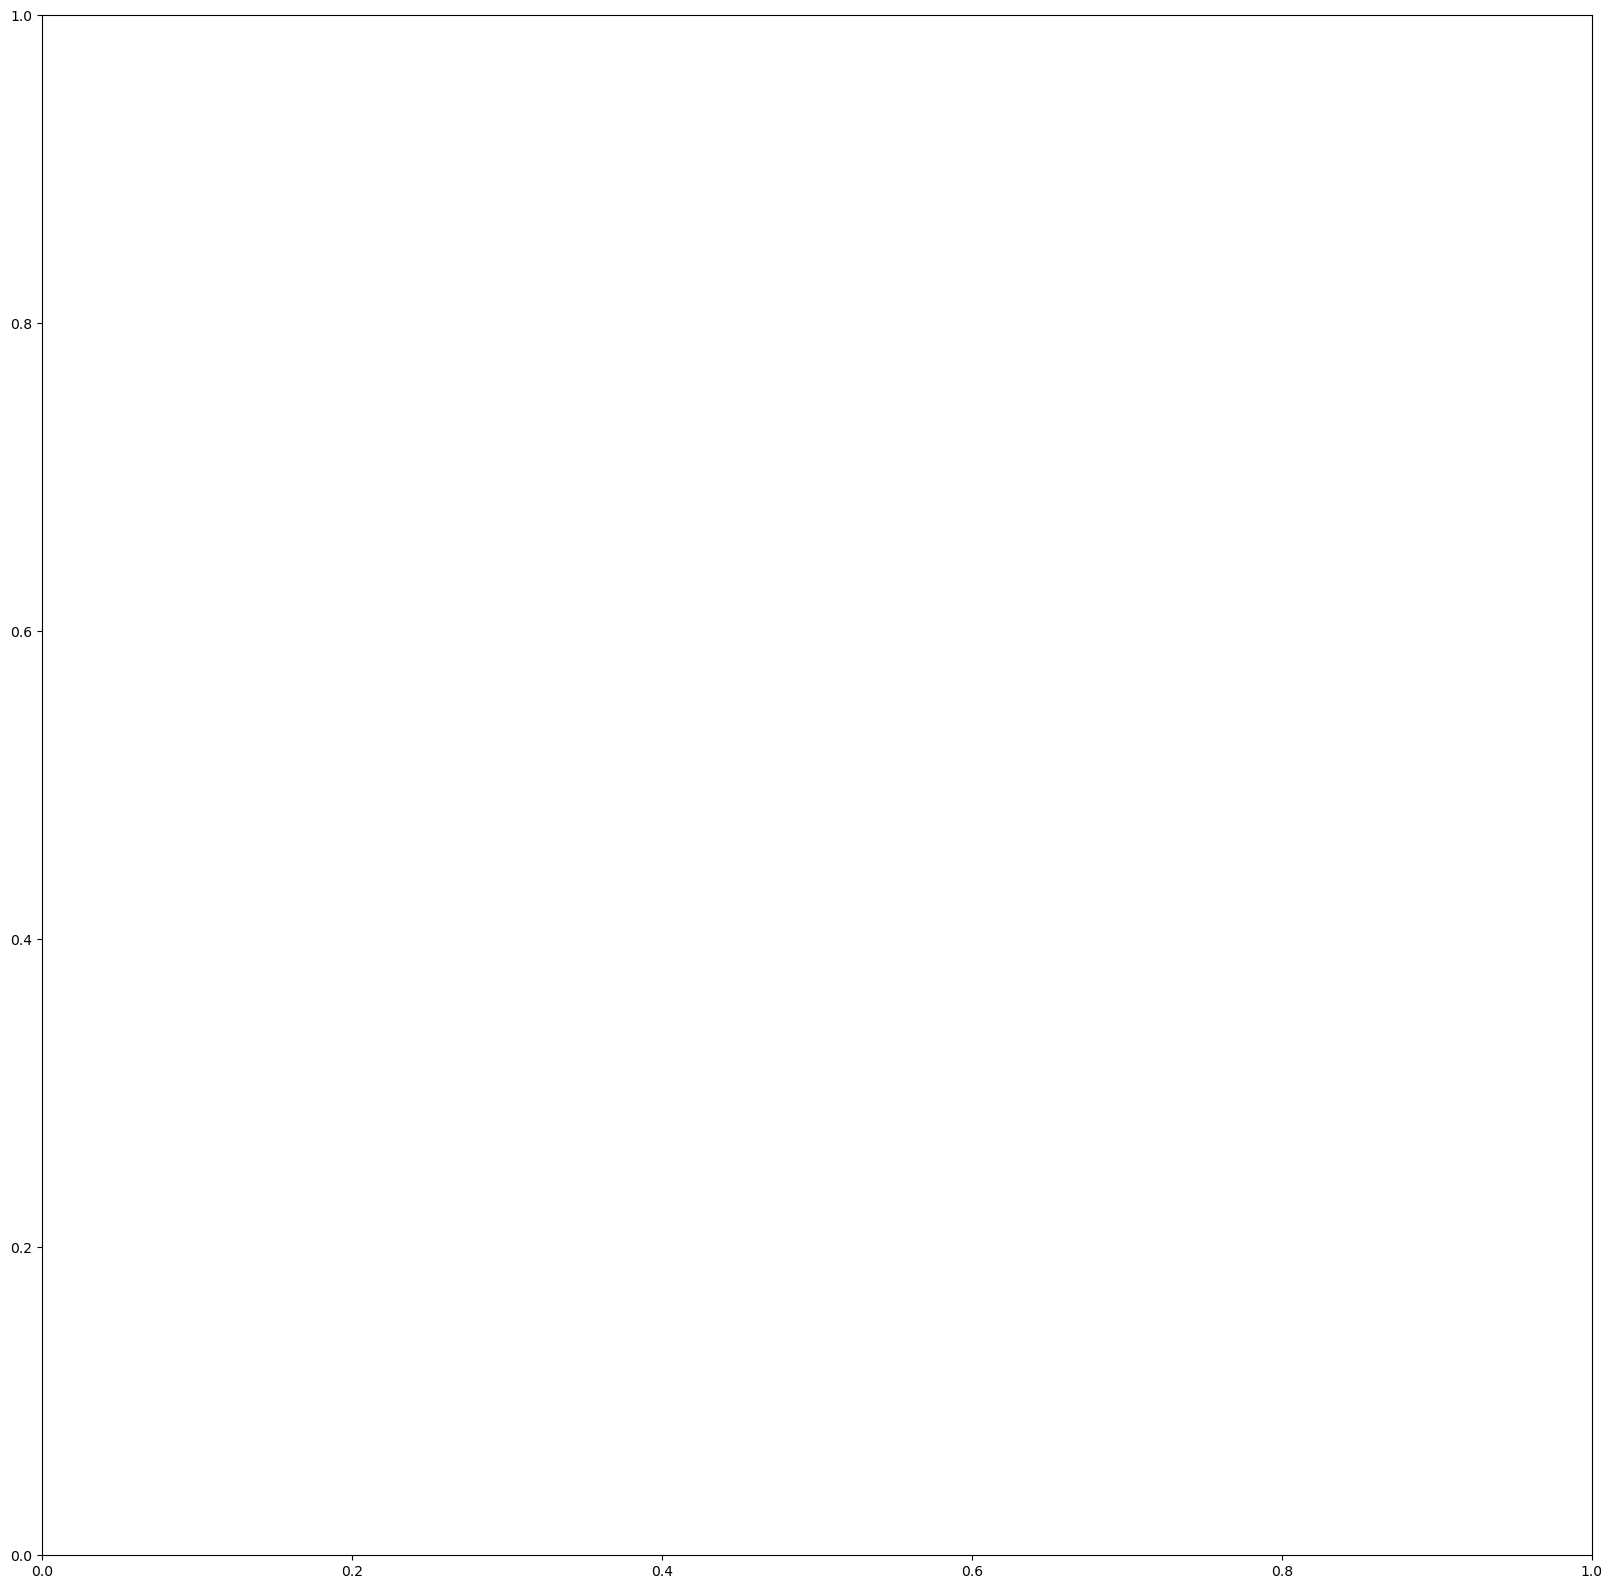

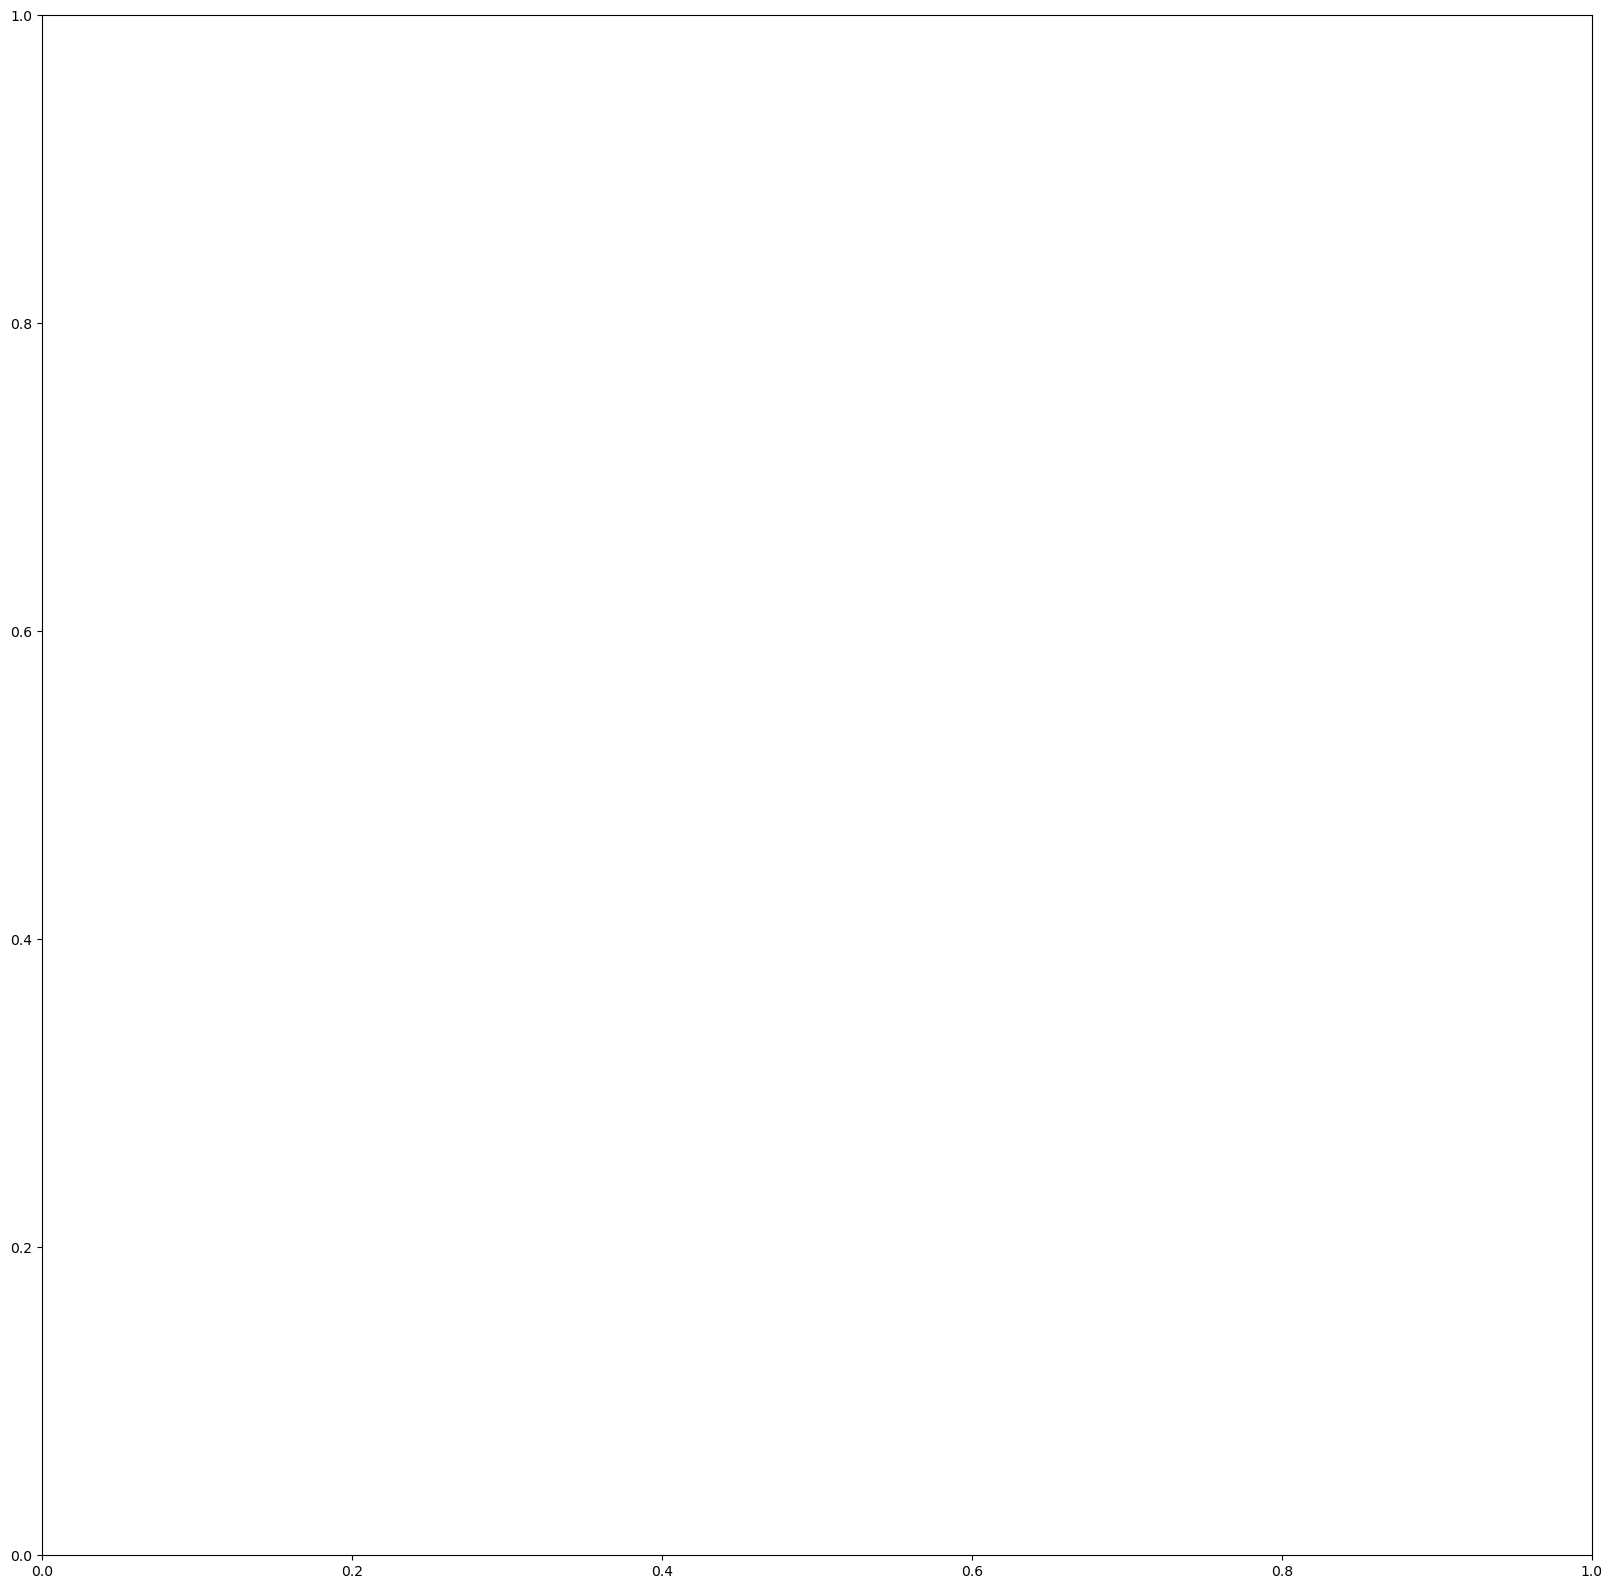

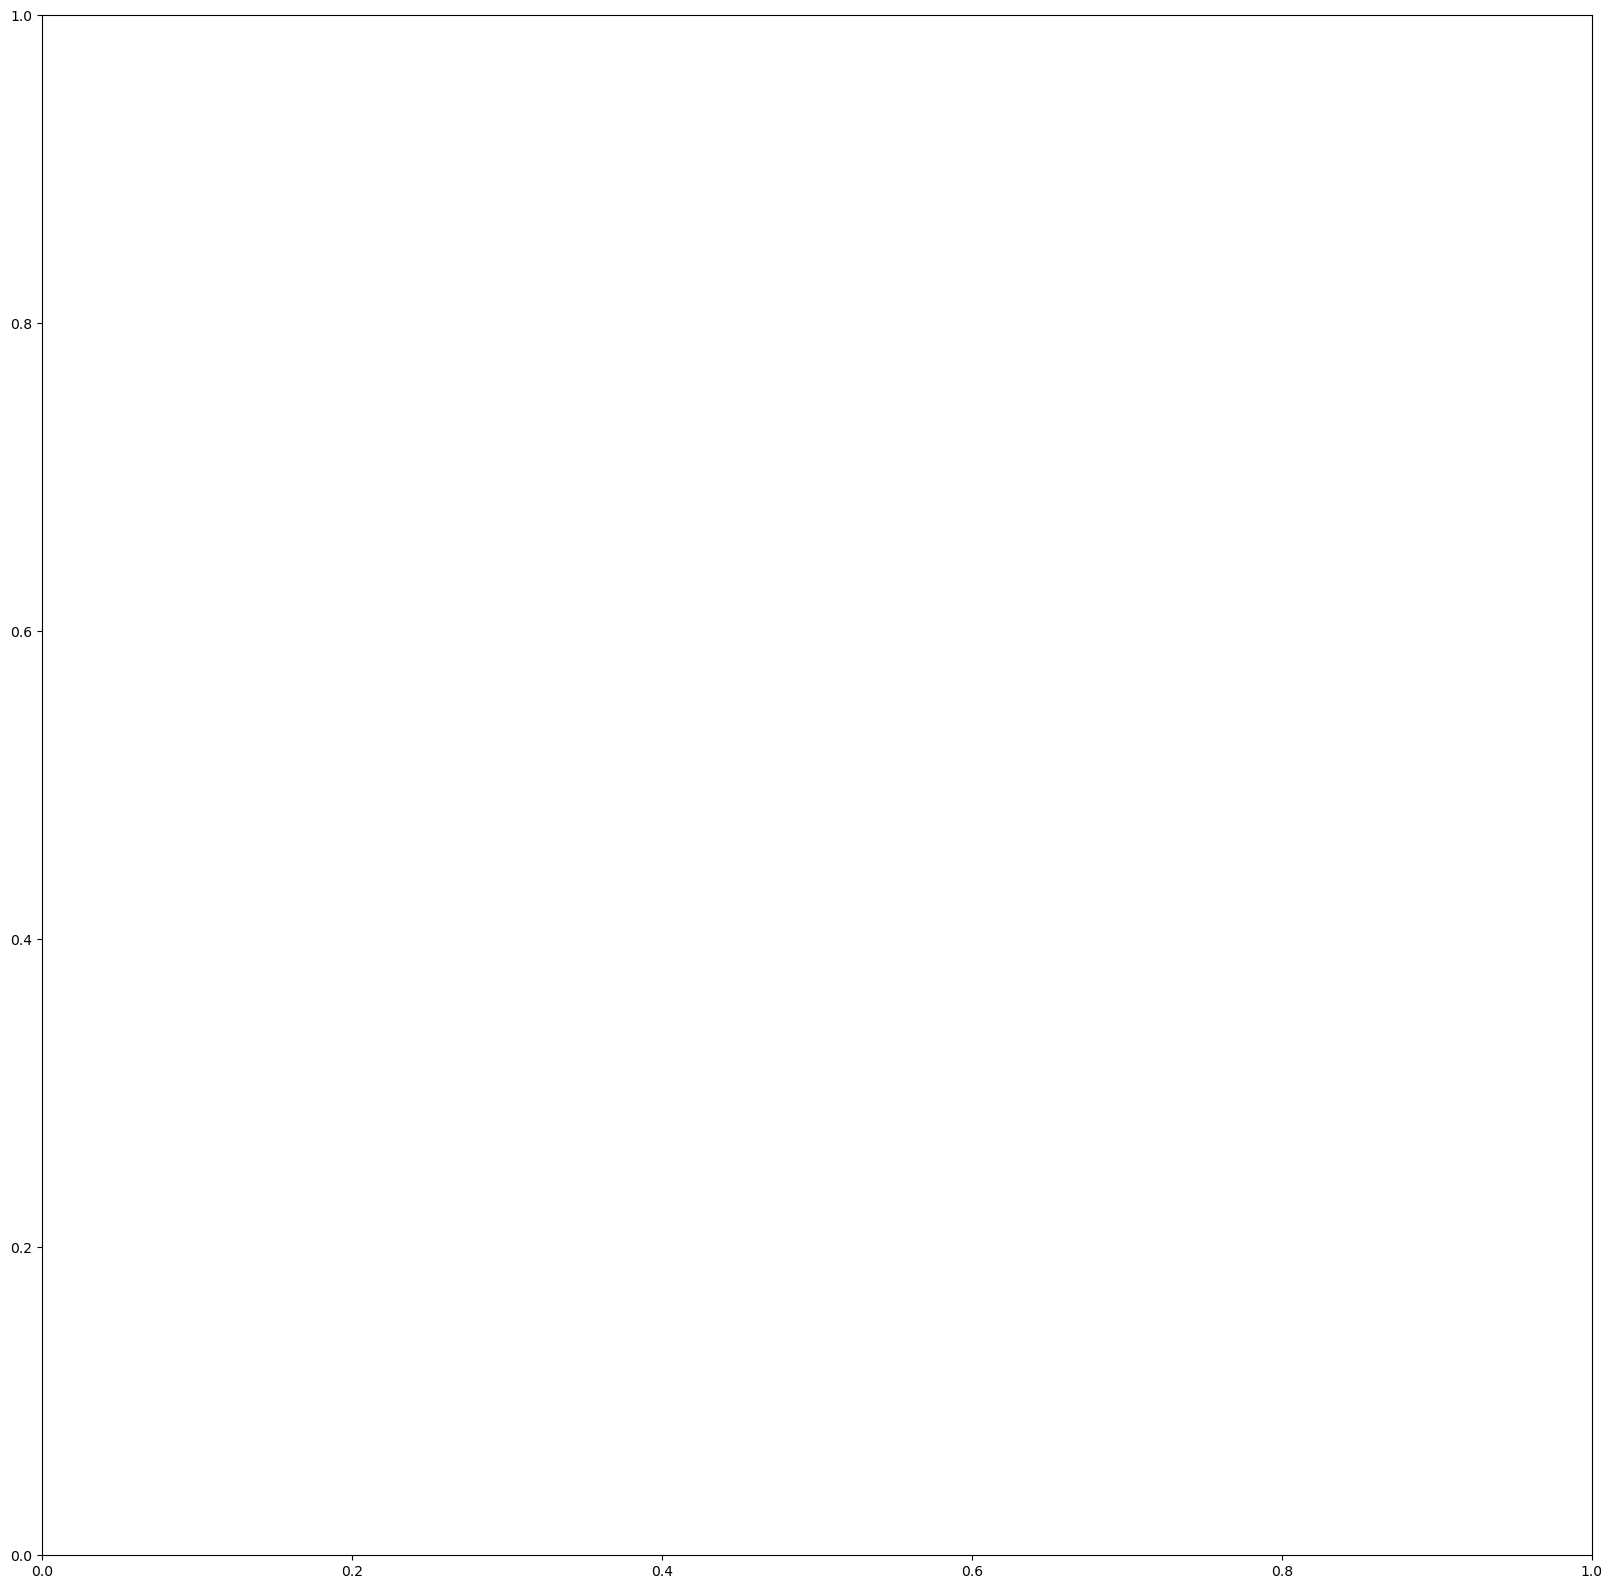

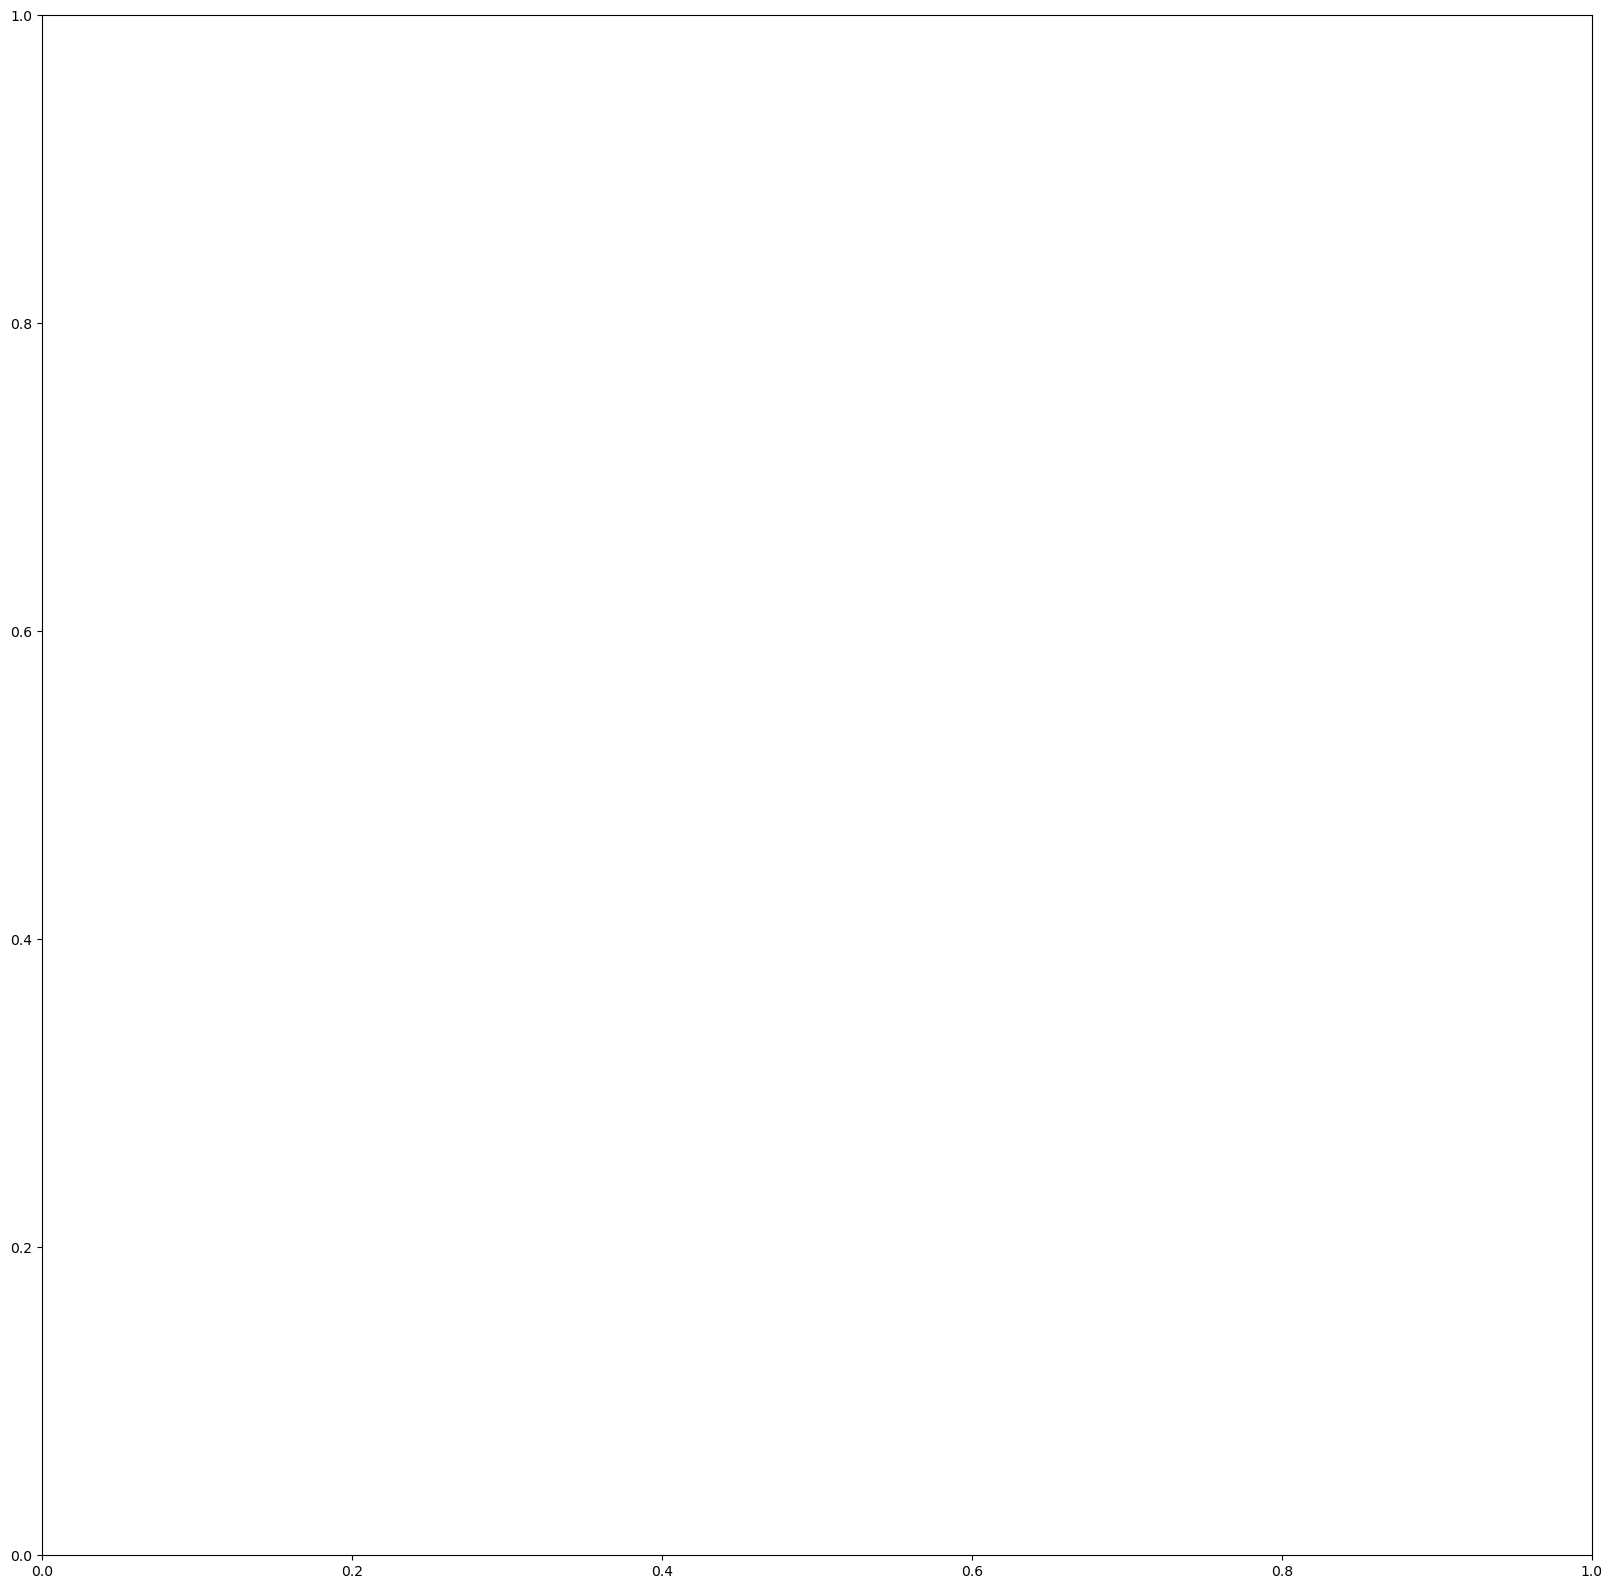

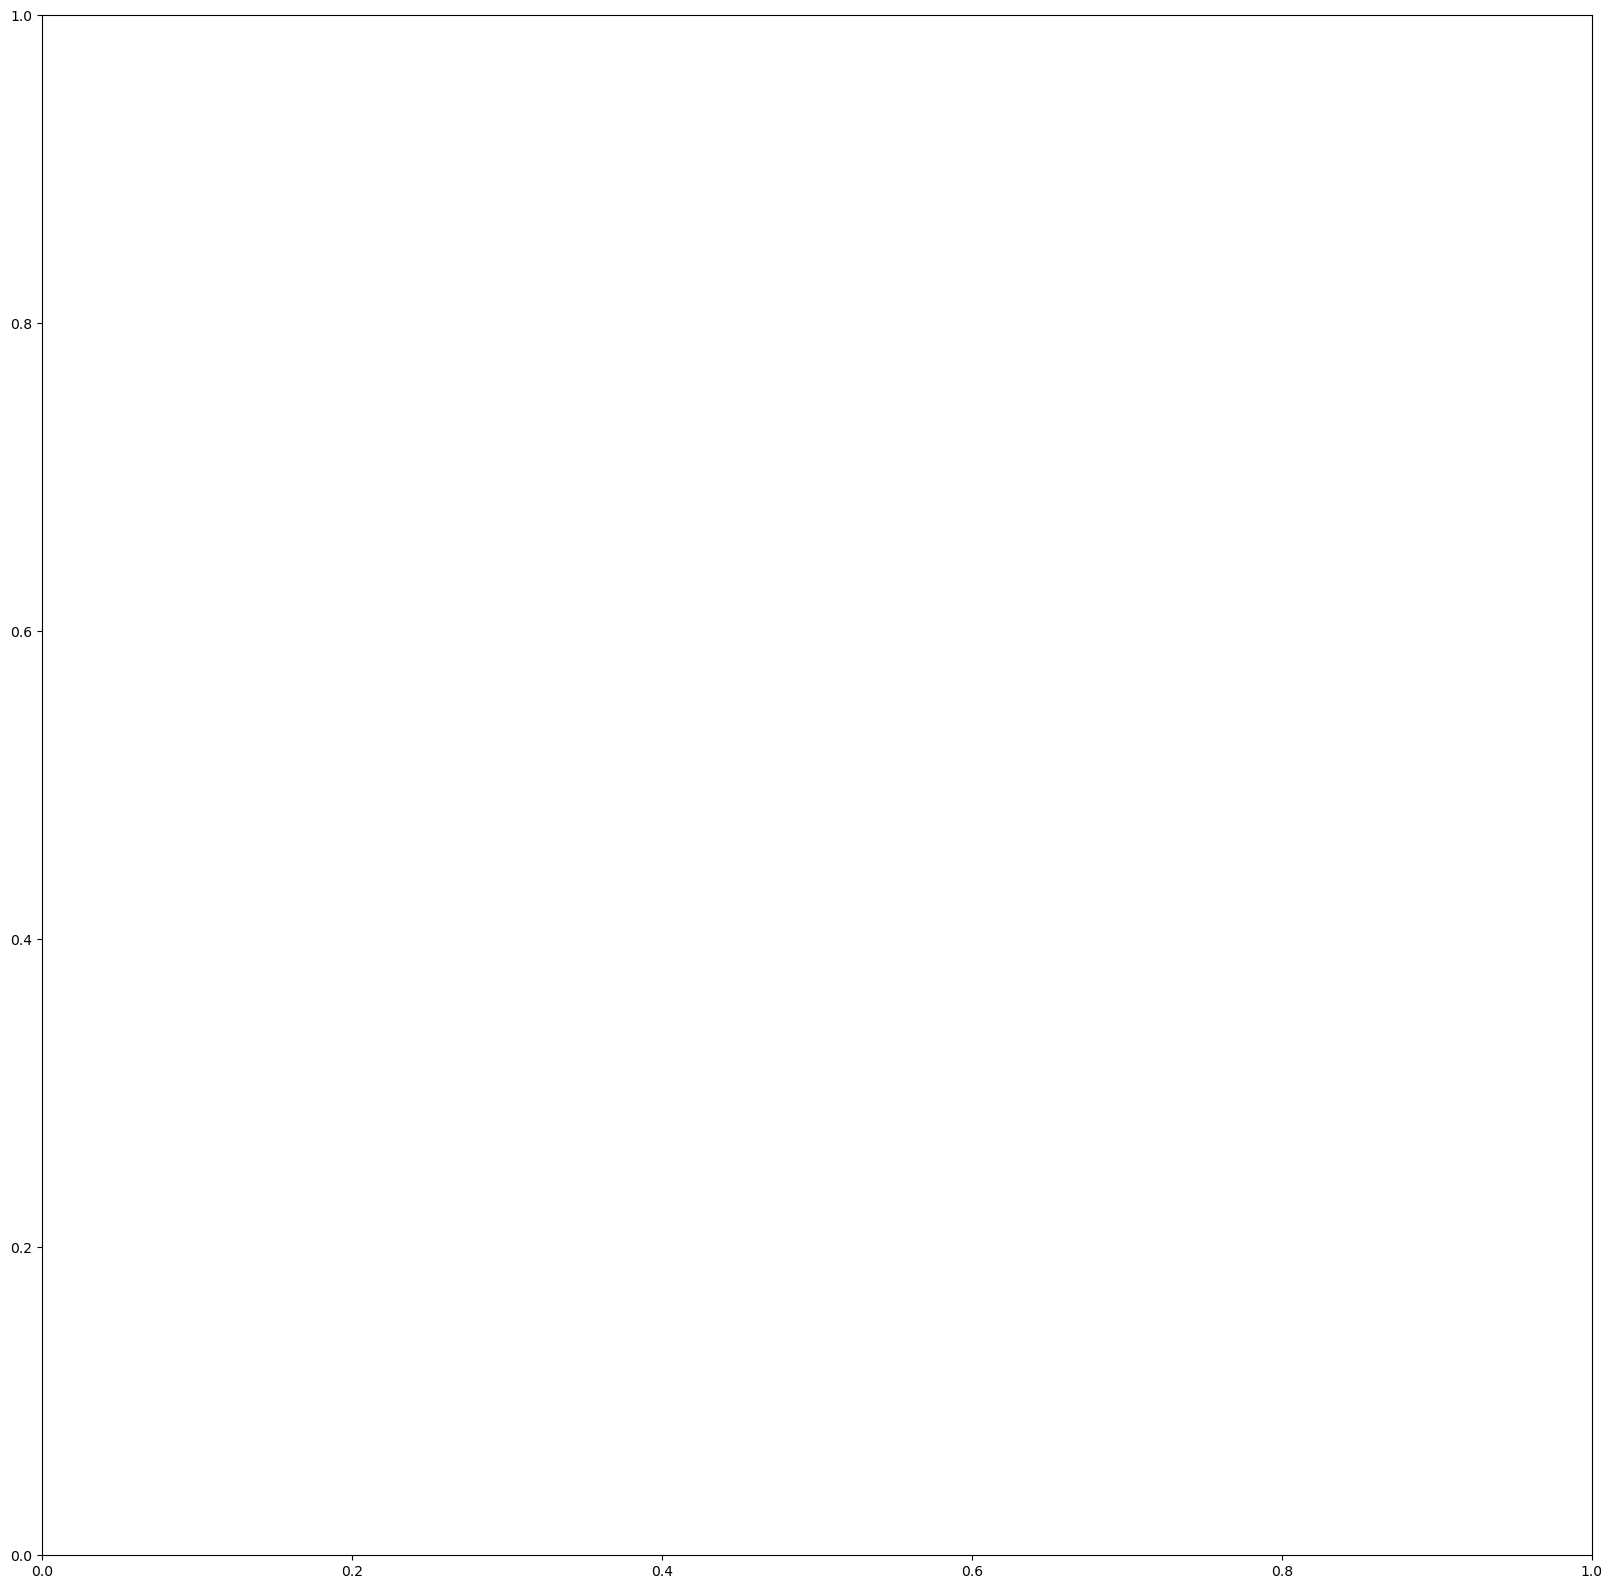

In [37]:
from sklearn.metrics import ConfusionMatrixDisplay
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
import warnings
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
names = ["K-Nearest Neighbors", "Liner SVM",
         "Decision Tree", "Random Forest",
         "ExtraTreesClassifier"]
classifiers = [
    KNeighborsClassifier(),
    LinearSVC(),
    DecisionTreeClassifier(),
    RandomForestClassifier(),
    ExtraTreesClassifier()]
clfF=[]
for name, clf in zip(names, classifiers):
    # Perform classification 
    model = clf
    model.fit(data_vect,labels)
    y_pred = model.predict(X_test)
    print(name)
    print(classification_report(y_test, y_pred))
    #cmt=confusion_matrix(y_test, y_pred)
    #cmp=ConfusionMatrixDisplay(confusion_matrix=cmt)
    fig, ax = plt.subplots(figsize=(20,20))
    #cmp.plot(ax=ax)
    #plt.title(name)
    #plt.show()
    print('--------------------------------------------------------------')
    clfF.append(model)

In [38]:
clfF

[KNeighborsClassifier(),
 LinearSVC(),
 DecisionTreeClassifier(),
 RandomForestClassifier(),
 ExtraTreesClassifier()]

In [39]:
import pickle
import bz2
sfile1 = bz2.BZ2File("All Model", 'w')
pickle.dump(clfF, sfile1) 
sfile2 = bz2.BZ2File("All Vector", 'w')
pickle.dump(vectorizer, sfile2) 